In [1]:
import pandas as pd
# import sys
# sys.path.append("../Handlers")
# import url_preprocessing

Record of urls after cleaning (missing Urls, invalid Urls, duplicate Urls):

Starting URL dataset cleanup...

Removed 0 rows with missing URLs

Removed 13 invalid URLs

Removed 17288 duplicate URLs

Cleanup completed!

Original count: 651191

Final count: 633889

Total removed: 17302

In [2]:
# df.to_csv("./malicious_phish_cleaned.csv")

<code>df = pd.read_csv("./malicious_phish_cleaned.csv")</code>

<code>df = url_preprocessing.extract_url_features()</code>

<code>df.to_csv("./malicious_phish_preprocessed.csv")</code>

In [3]:
df = pd.read_csv("./malicious_phish_preprocessed.csv")

benign        422930
defacement     94915
phishing       92405
malware        23639
Name: type, dtype: int64


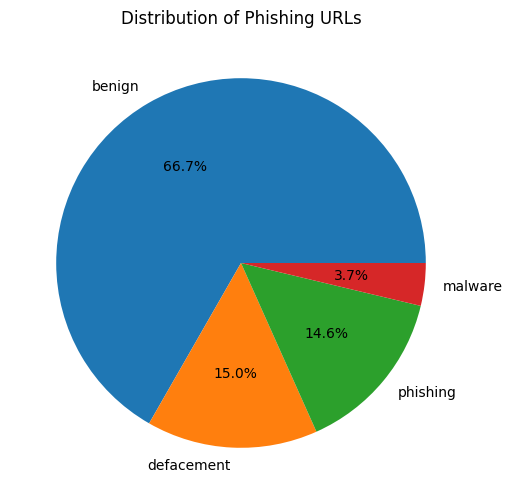

In [4]:
import matplotlib.pyplot as plt
import os

# Four types: benign, phishing, defacement and malware
label_counts = df['type'].value_counts()

print(label_counts)

plt.figure(figsize=(10, 6))
plt.pie(label_counts.values, labels=["benign", "defacement", "phishing", "malware"], autopct='%1.1f%%')
plt.title('Distribution of Phishing URLs')
plt.savefig(os.path.join("./figs", "phishing_types_distribution.png"), bbox_inches='tight')
plt.show()

In [5]:
X = df.drop(columns=["Unnamed: 0", "url", "type"])
y = df["type"]
del df

In [6]:
X = pd.get_dummies(X, columns=["tld"], drop_first=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
# from multiclass_traintest import train_and_evaluate_models

# metric_results = []

# train_and_evaluate_models(X, y, "Malicious_Phish", metric_results, threading=True, max_workers=4)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def evaluate_and_predict_proba(model, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)[:, 0]

    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
lr = LogisticRegression(multi_class="multinomial")

In [12]:
lr.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0     0.7234    0.9112    0.8065     84729
           1     0.5513    0.1264    0.2056     18909
           2     0.0000    0.0000    0.0000      4761
           3     0.4718    0.4036    0.4350     18379

    accuracy                         0.6863    126778
   macro avg     0.4366    0.3603    0.3618    126778
weighted avg     0.6341    0.6863    0.6327    126778



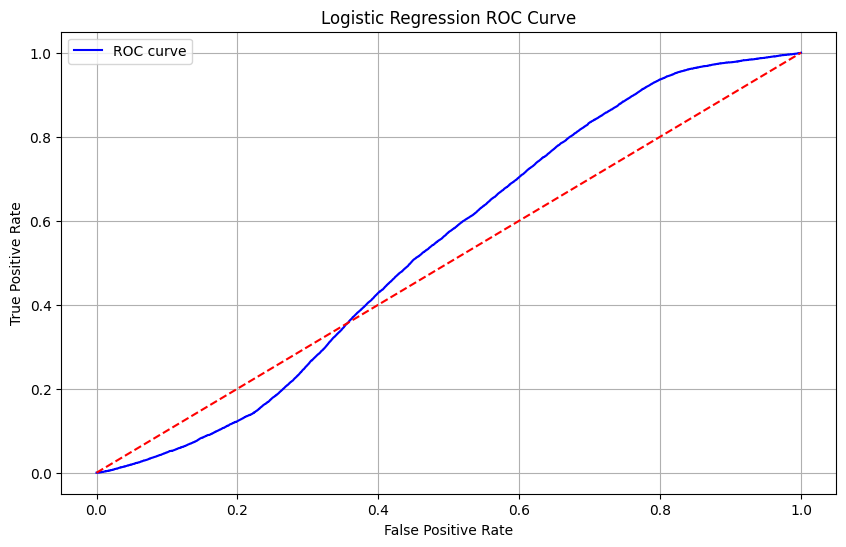

In [13]:
y_pred = lr.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4))

evaluate_and_predict_proba(lr, title="Logistic Regression ROC Curve")

del lr

In [14]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

sgd = OneVsRestClassifier(LinearSVC(), n_jobs=3)
sgd.fit(X_train, y_train)

OneVsRestClassifier(estimator=LinearSVC(), n_jobs=3)

In [ ]:
y_pred = sgd.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

del sgd

              precision    recall  f1-score   support

           0     0.8112    0.8063    0.8087     84729
           1     0.9370    0.1204    0.2134     18909
           2     0.2632    0.0011    0.0021      4761
           3     0.3436    0.7499    0.4713     18379

    accuracy                         0.6656    126778
   macro avg     0.5887    0.4194    0.3739    126778
weighted avg     0.7416    0.6656    0.6407    126778



AttributeError: This 'OneVsRestClassifier' has no attribute 'predict_proba'

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=3)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=3)

              precision    recall  f1-score   support

           0     0.9488    0.9653    0.9570     84729
           1     0.9377    0.9090    0.9231     18909
           2     0.9725    0.9210    0.9461      4761
           3     0.8841    0.8531    0.8684     18379

    accuracy                         0.9390    126778
   macro avg     0.9358    0.9121    0.9236    126778
weighted avg     0.9387    0.9390    0.9387    126778



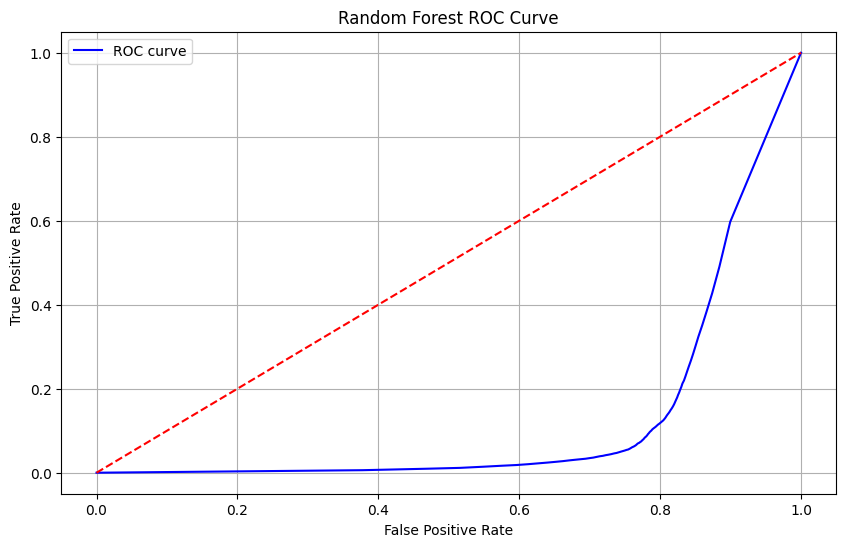

In [17]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

evaluate_and_predict_proba(rf, title="Random Forest ROC Curve")

del rf

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

              precision    recall  f1-score   support

           0     0.9522    0.9471    0.9496     84729
           1     0.8889    0.9086    0.8987     18909
           2     0.9400    0.9443    0.9422      4761
           3     0.8602    0.8610    0.8606     18379

    accuracy                         0.9288    126778
   macro avg     0.9103    0.9153    0.9128    126778
weighted avg     0.9290    0.9288    0.9288    126778



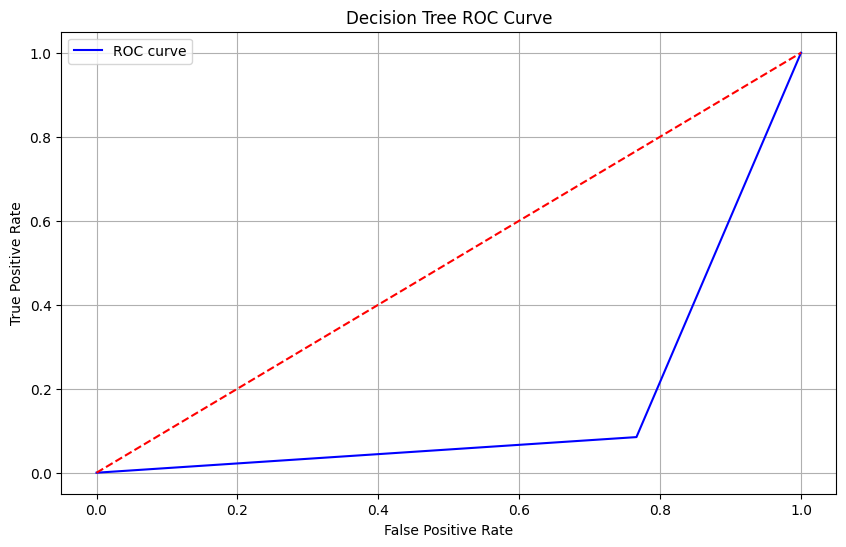

In [19]:
y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

evaluate_and_predict_proba(dt, title="Decision Tree ROC Curve")

del dt

In [20]:
from sklearn.ensemble import ExtraTreesClassifier

xt = ExtraTreesClassifier(n_jobs=3)
xt.fit(X_train, y_train)

ExtraTreesClassifier(n_jobs=3)

              precision    recall  f1-score   support

           0     0.9382    0.9644    0.9511     84729
           1     0.9362    0.8803    0.9074     18909
           2     0.9676    0.9099    0.9379      4761
           3     0.8741    0.8288    0.8508     18379

    accuracy                         0.9301    126778
   macro avg     0.9290    0.8958    0.9118    126778
weighted avg     0.9297    0.9301    0.9296    126778



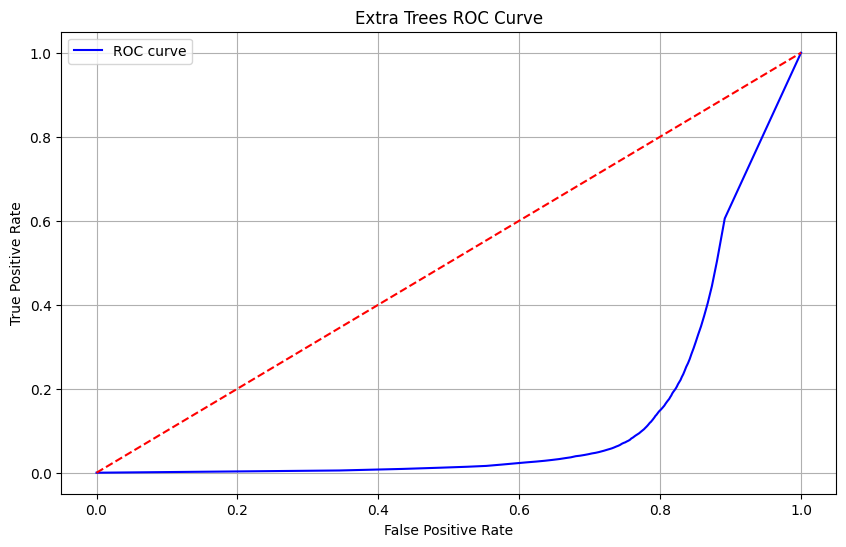

In [21]:
y_pred = xt.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

evaluate_and_predict_proba(xt, title="Extra Trees ROC Curve")

del xt

In [ ]:
from sklearn.linear_model import Perceptron

p = OneVsRestClassifier(Perceptron(n_jobs=2), n_jobs=2)
p.fit(X_train, y_train)

OneVsRestClassifier(estimator=Perceptron(n_jobs=2), n_jobs=2)

In [ ]:
y_pred = p.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

del p

e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0     0.6705    0.9894    0.7993     84729
           1     0.4030    0.0375    0.0687     18909
           2     0.0000    0.0000    0.0000      4761
           3     0.0000    0.0000    0.0000     18379

    accuracy                         0.6668    126778
   macro avg     0.2684    0.2567    0.2170    126778
weighted avg     0.5082    0.6668    0.5445    126778



AttributeError: This 'OneVsRestClassifier' has no attribute 'predict_proba'

In [24]:
from sklearn.linear_model import PassiveAggressiveClassifier

pa = OneVsRestClassifier(PassiveAggressiveClassifier(n_jobs=2), n_jobs=2)
pa.fit(X_train, y_train)

OneVsRestClassifier(estimator=PassiveAggressiveClassifier(n_jobs=2), n_jobs=2)

In [ ]:
y_pred = pa.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

del pa

              precision    recall  f1-score   support

           0     0.7557    0.8556    0.8025     84729
           1     0.2380    0.3869    0.2947     18909
           2     0.0000    0.0000    0.0000      4761
           3     0.0952    0.0005    0.0011     18379

    accuracy                         0.6296    126778
   macro avg     0.2722    0.3108    0.2746    126778
weighted avg     0.5543    0.6296    0.5805    126778



e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


AttributeError: This 'OneVsRestClassifier' has no attribute 'predict_proba'

In [26]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()
nb.fit(X_train, y_train)

BernoulliNB()

              precision    recall  f1-score   support

           0     0.7902    0.8121    0.8010     84729
           1     0.4865    0.7081    0.5767     18909
           2     0.9126    0.6295    0.7451      4761
           3     0.3988    0.1931    0.2602     18379

    accuracy                         0.7000    126778
   macro avg     0.6470    0.5857    0.5958    126778
weighted avg     0.6928    0.7000    0.6871    126778



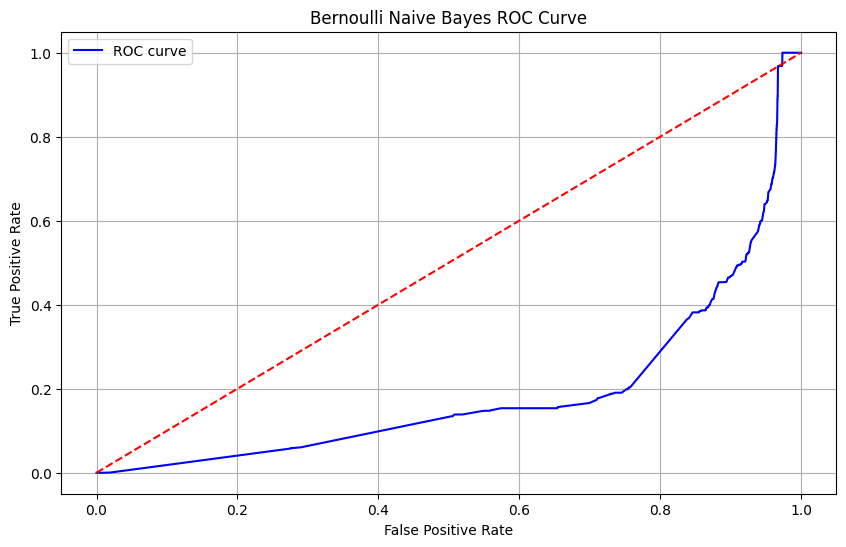

In [27]:
y_pred = nb.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

evaluate_and_predict_proba(nb, title="Bernoulli Naive Bayes ROC Curve")

del nb